# CS 383 - Machine Learning
## Lab 4 - Gradient-Based Learning

### Introduction
In this lab you will implement a gradient based approach of linear regression using a simple toy dataset.\\

As with all labs, you cannot use any functions that are against the "spirit" of the lab.  

### Grading
| Points | Description |
| ------- | --------|
|  +1pt|   Create dataset correctly | 
|  +1pt|  Does some gradient based computations. | 
|  +1pt|  Does some learning.| 
|  +1pt|  Correct termination criteria set up.| 
|  +1pt|  Creates some plot.| 
|  +2pts|  Creates correct plot.| 
|  +1pt|  Runs to convergence.| 
|  +2pts | Learned parameters are correct.| 
| ------ | ------ |
| 10pts | Total |

### Our Data
Let's look to learn the model $y=3x-5$.  Create a dataset that has three points on this line.  For example, one point is $x=0, y=-5.$
Create a dataset with $3$ points along the line $y=3x-5$.  Therefore, our data matrix should be $X\in \mathbb{R}^{3\times1}, Y\in \mathbb{R}^{3\times1}$

In [80]:
#TODO
#Create your observable data matrix as X and Target matrix as Y
import numpy as np
X = np.array([[0],[1],[2]])
Y = np.array([[-5],[-2],[1]])
print(X)
print(Y)

[[0]
 [1]
 [2]]
[[-5]
 [-2]
 [ 1]]


### Gradient-Based Linear Regression
Now design, implement and train a \emph{Graidient-Based Linear Regression Model} using the training data you created.  

In the cell below, train a linear regression model using a gradient-based approach, computing the mean squared error each epoch.

#### Implementation Details
- For illustrative purposes **DO NOT** z-score your data (features are on the same scale anyway)
- Seed the random number generate with zero prior to randomizing the data
- We will let you determine appropriate values for the learning rate, $\eta$, the initial parameter values, as well as an appropriate termination criteria. 
- Make sure to add a bias feature.
- For full credit, you must run your algorithm to *convergence* (or at least until visually it pretty much flattens out).


In [81]:
#TODO Create linear regression model
X2 = np.concatenate((X, np.ones((X.shape[0],1))),axis=1)
W = np.array([[1],[1]])
print(X2)
print(W)
N = X2.shape[0]
print(N)

MAX_EPOCHS = 100
learningRate = 0.25

losses = []
epochs = []

for i in range(MAX_EPOCHS):
    yhati= X2@W
    dJdw = (2/N) * (X2.T @ (yhati - Y))
    W = W - learningRate*dJdw
    
    loss = np.mean((Y-yhati)**2)
    losses.append(loss)
    epochs.append(i+1)

print("W after", MAX_EPOCHS, "epochs")
print(W)
    

[[0. 1.]
 [1. 1.]
 [2. 1.]]
[[1]
 [1]]
3
W after 100 epochs
[[ 2.99999896]
 [-4.99999856]]


### Evaluation
Finally, using your model to make predictions for your four observations, then compute the RMSE and SMAPE for this training data.   Also display the learned weights

In [82]:
Yhat = X2@W
MSE = np.mean((Y-Yhat)**2)
RMSE = MSE**(1/2)
print("RMSE:")
print(RMSE)

N = Yhat.shape[0]
SMAPE = np.mean((np.abs(Y - Yhat) / (np.abs(Y) + (np.abs(Yhat)))))
print("SMAPE:")
print(SMAPE)

print("Learned weights:")
print(W)

RMSE:
9.393176157150694e-07
SMAPE:
1.877373358911549e-07
Learned weights:
[[ 2.99999896]
 [-4.99999856]]


### Visualize Training Process
Finally let's visualize the training process by plotting the number of epochs (y-axis) vs mean log loss (x-axis)

[np.float64(18.666666666666668), np.float64(7.851851851851851), np.float64(5.588477366255144), np.float64(4.128486511202561), np.float64(3.055809581872682), np.float64(2.2620606050342373), np.float64(1.6744968710857215), np.float64(1.2395514384823878), np.float64(0.9175817612894761), np.float64(0.6792427188228595), np.float64(0.5028115101597387), np.float64(0.3722077657124953), np.float64(0.27552794249417045), np.float64(0.20396040622567432), np.float64(0.1509823175506865), np.float64(0.11176512458870956), np.float64(0.08273447697036602), np.float64(0.061244450849487236), np.float64(0.04533639296709099), np.float64(0.03356040422858497), np.float64(0.024843192373146944), np.float64(0.01839024950609805), np.float64(0.01361343871659996), np.float64(0.010077389848852756), np.float64(0.007459818806979949), np.float64(0.005522153798516242), np.float64(0.004087791320874318), np.float64(0.003026000088499023), np.float64(0.0022400058654749463), np.float64(0.0016581712262444279), np.float64(0.00

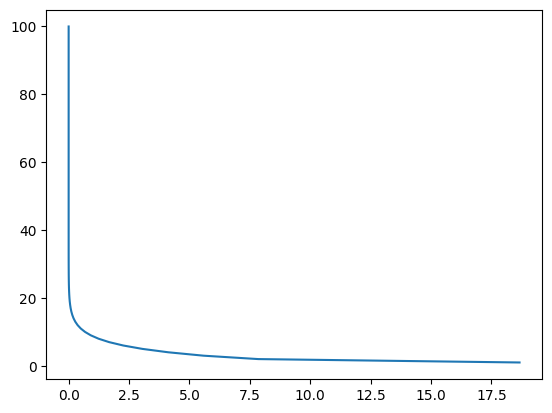

In [83]:
#TODO  Visualize Training Process
import matplotlib.pyplot as plt
print(losses)
print(epochs)
x = np.array(losses)
y = np.array(epochs)
plt.plot(x,y)
plt.show()